In [53]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [55]:
from src.data.ingestion import load_data

df = load_data("../data/feature_engineered/gurgaon_properties_cleaned_v2.csv")

Dataset loaded successfully.
Rows: 3803
Columns: 23


In [56]:
df.duplicated().sum()

np.int64(126)

In [57]:
df.drop_duplicates(inplace=True)

In [58]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80


In [59]:
df.shape

(3677, 23)

In [60]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

<Axes: xlabel='price', ylabel='Count'>

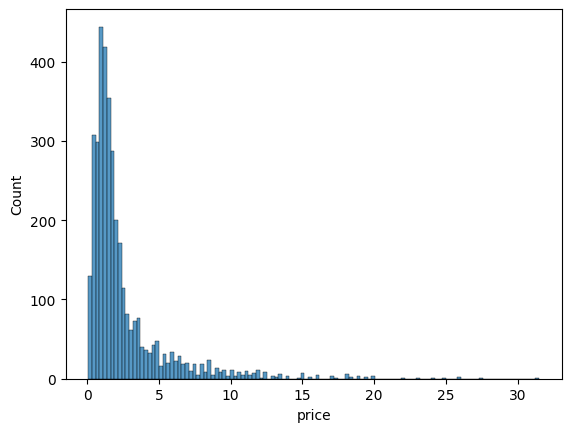

In [61]:
# outliers on the basis of price column
sns.histplot(df['price'])

<Axes: xlabel='price'>

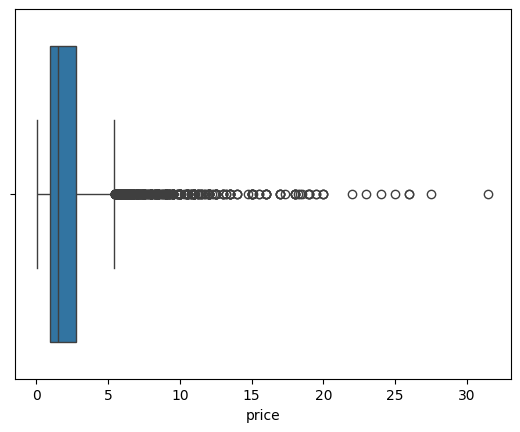

In [62]:
sns.boxplot(x=df['price'])

In [63]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [64]:
outliers

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
6,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
8,house,independent,sector 46,5.65,23870.0,2367.0,Plot area 263(219.9 sq.m.),8,6,3+,3.0,South-West,Moderately Old,NaN,2367.0,NaN,0,1,0,0,0,1,67
18,house,independent,sector 55,5.60,20741.0,2700.0,Plot area 300(250.84 sq.m.),6,4,3,3.0,East,Old Property,NaN,2700.0,NaN,0,1,0,0,0,1,41
40,house,independent,sector 82,7.00,21605.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,1.0,North-East,Relatively New,NaN,3240.0,NaN,1,1,0,1,0,1,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3757,house,international city by sobha phase 2,sector 109,10.00,27778.0,3600.0,Plot area 400(334.45 sq.m.),4,5,3+,2.0,East,New Property,NaN,3600.0,NaN,1,1,0,1,1,1,49
3777,house,independent,sector 55,7.49,27741.0,2700.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,Relatively New,NaN,2700.0,NaN,1,1,0,1,0,1,49
3789,flat,krrish provence estate,gwal pahari,7.50,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49
3797,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0,1,0,1,0,1,49


In [65]:
outliers.to_excel(
    "../reports/outliers/price_outliers.xlsx",
    index=False
)

# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

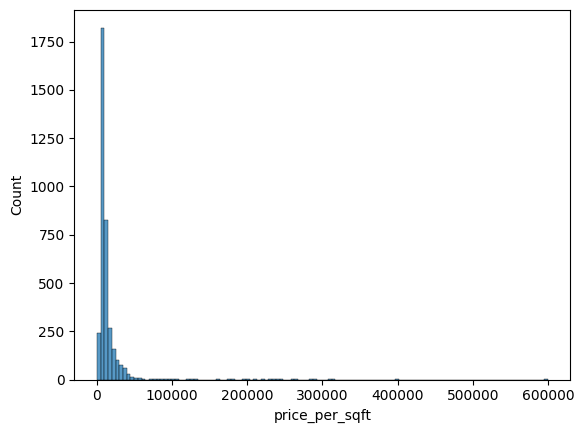

In [66]:
sns.histplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

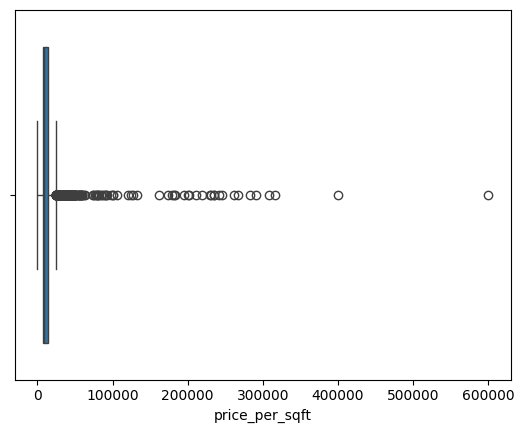

In [67]:
sns.boxplot(x=df['price_per_sqft'])

In [68]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [69]:
outliers_sqft.to_excel(
    "../reports/outliers/price_per_sqft_outliers.xlsx",
    index=False
)

In [70]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\user\AppData\Local\Temp\ipykernel_10452\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [71]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\user\AppData\Local\Temp\ipykernel_10452\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [72]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [73]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

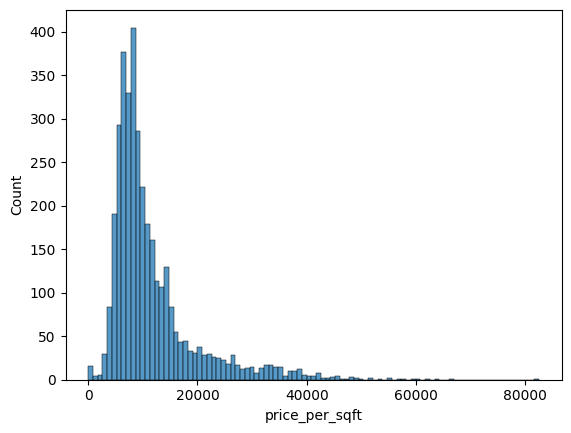

In [74]:
sns.histplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

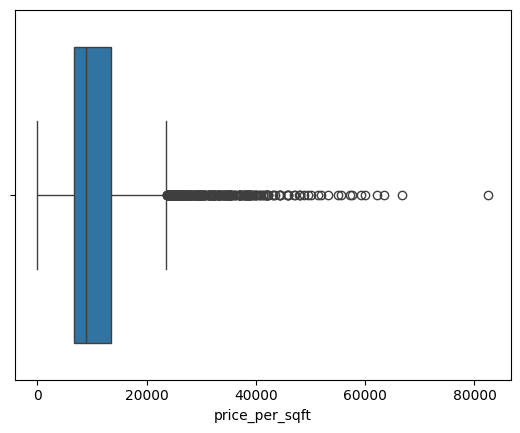

In [75]:
sns.boxplot(x=df['price_per_sqft'])

In [77]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
56,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,1,103
139,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
808,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
998,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0
1176,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,1,153
1377,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,1,72
1842,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0
2600,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,2,75
2915,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
2955,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,2,137


In [78]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

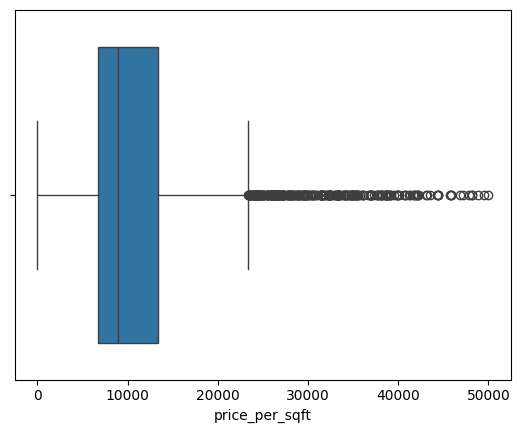

In [79]:
sns.boxplot(x=df['price_per_sqft'])

### Area


<Axes: xlabel='area', ylabel='Count'>

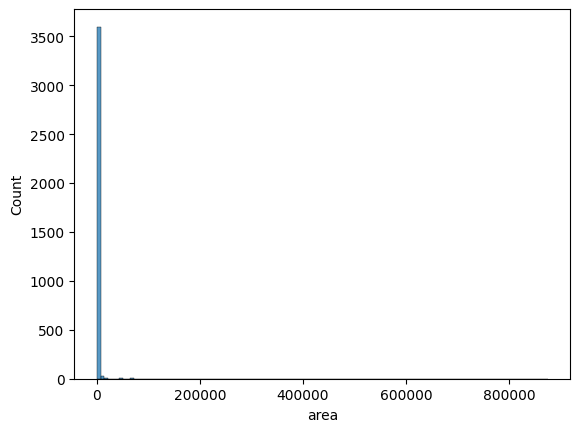

In [80]:
sns.histplot(df['area'])


<Axes: xlabel='area'>

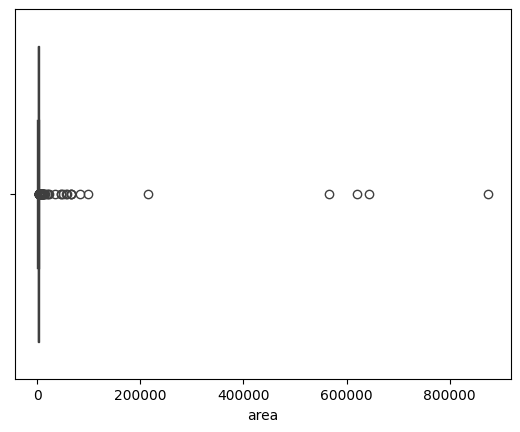

In [81]:
sns.boxplot(x=df['area'])

In [82]:
df['area'].describe()

count      3647.000000
mean       2947.723608
std       23208.194102
min         145.000000
25%        1262.000000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [83]:
df = df[df['area'] <100000]

<Axes: xlabel='area', ylabel='Count'>

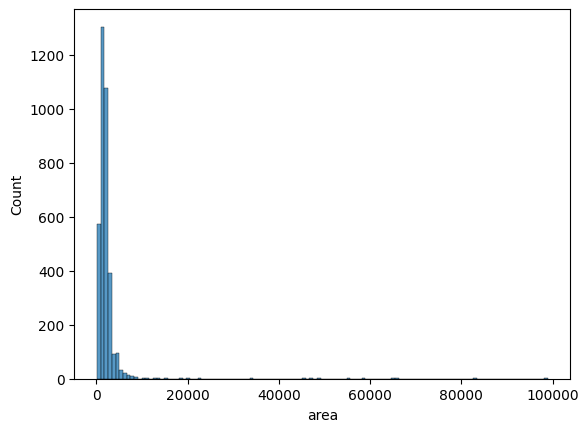

In [84]:
sns.histplot(df['area'])

<Axes: xlabel='area'>

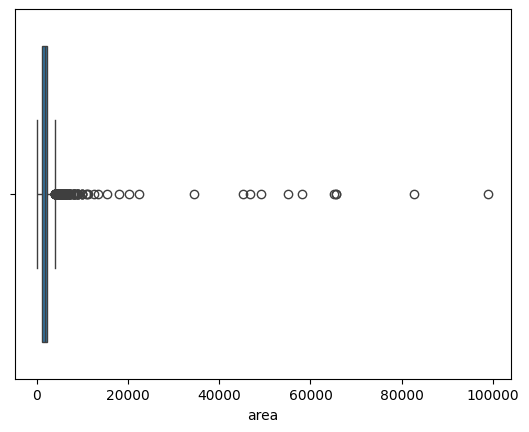

In [85]:
sns.boxplot(x=df['area'])

In [86]:
area_greater_than_10000 = df[df['area'] > 10000].sort_values('area',ascending=False)
area_greater_than_10000


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3679,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
1640,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2499,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
324,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
2125,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
333,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
1974,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
762,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
3511,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2346,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [87]:
df.shape

(3642, 23)

In [88]:
area_greater_than_10000.to_excel(
    "../reports/outliers/area_greater_than_10000.xlsx",
    index=False
)

In [89]:
area_greater_than_10000['area_per_room'] = area_greater_than_10000['area'] / (area_greater_than_10000['bedRoom'] + area_greater_than_10000['bathroom'])
area_greater_than_10000['area_per_room'].sort_values(ascending=False)

762     24561.500000
2735    17213.000000
324     16379.250000
333     14557.000000
1974    13750.000000
2499    13103.400000
2346    11320.750000
3679     7069.857143
1640     5173.812500
2125     3263.050000
3511     2599.722222
3359     2579.833333
676      2248.666667
2738     2107.500000
43       2014.333333
1413     1799.833333
2775     1375.000000
2343     1350.000000
2017     1249.888889
1164      868.153846
Name: area_per_room, dtype: float64

In [90]:
area_greater_than_10000

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_per_room
3679,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60,7069.857143
1640,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7,5173.812500
2499,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51,13103.400000
324,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15,16379.250000
2125,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0,3263.050000
333,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15,14557.000000
1974,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37,13750.000000
762,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37,24561.500000
3511,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109,2599.722222
2346,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33,11320.750000


In [91]:
index=area_greater_than_10000[(area_greater_than_10000['area_per_room'] > 4000) & (area_greater_than_10000['price'] < 1.0)].index

In [92]:
df.drop(index, inplace=True)

In [93]:
df.shape

(3635, 23)

In [94]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3679,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
1640,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2125,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
3511,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2017,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,1,61
2343,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,1,123
43,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44
3359,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.00,0,1,0,0,0,0,160
676,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0
2738,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55


In [95]:
large_area = df[df['area'] > 10000].copy()

In [96]:
large_area

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
43,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44
676,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0
1164,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
1413,house,independent,sohna road road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,NaN,3500.0,NaN,1,1,0,1,1,0,49
1640,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2017,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,1,61
2125,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2343,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,1,123
2738,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
2775,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [97]:
large_area['max_area'] = large_area[
    ['super_built_up_area', 'built_up_area', 'carpet_area']
].max(axis=1)

In [98]:
large_area

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,max_area
43,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44,18122.00
676,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0,13500.00
1164,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42,11286.00
1413,house,independent,sohna road road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,NaN,3500.0,NaN,1,1,0,1,1,0,49,3500.00
1640,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7,115.00
2017,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,1,61,2660.00
2125,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0,7250.00
2343,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,1,123,2850.00
2738,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55,1175.11
2775,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,0,60,11000.00


In [99]:
large_area['total_rooms'] = large_area['bedRoom'] + large_area['bathroom']

In [100]:
large_area['area_per_room'] = large_area['max_area'] / large_area['total_rooms']

In [101]:
large_area.sort_values('area_per_room', ascending=False)[
    ['property_type', 'sector', 'price',
     'super_built_up_area', 'built_up_area', 'carpet_area',
     'max_area', 'bedRoom', 'bathroom', 'area_per_room']
]

,property_type,sector,price,super_built_up_area,built_up_area,carpet_area,max_area,bedRoom,bathroom,area_per_room
676,house,sector 4,0.85,NaN,13500.0,NaN,13500.00,3,3,2250.000000
43,flat,sector 85,2.50,NaN,NaN,18122.00,18122.00,4,5,2013.555556
2775,flat,sector 65,13.20,NaN,NaN,11000.00,11000.00,4,4,1375.000000
1164,house,sector 43,27.50,NaN,11286.0,NaN,11286.00,6,7,868.153846
3679,house,sector 26,18.40,NaN,NaN,11000.00,11000.00,6,8,785.714286
1413,house,sohna road road,5.50,NaN,3500.0,NaN,3500.00,3,3,583.333333
2125,house,sector 28,13.00,NaN,NaN,7250.00,7250.00,10,10,362.500000
3359,house,sector 50,6.95,NaN,2160.0,1720.00,2160.00,3,3,360.000000
3511,house,sector 25,7.30,NaN,5800.0,5200.00,5800.00,9,9,322.222222
2738,flat,sector 88a,1.75,NaN,NaN,1175.11,1175.11,3,3,195.851667


In [102]:
df.loc[large_area.index, 'area'] = large_area['max_area']

In [103]:
idx_to_drop=large_area[large_area['area_per_room'] < 150].index
df.drop(idx_to_drop, inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_10452\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

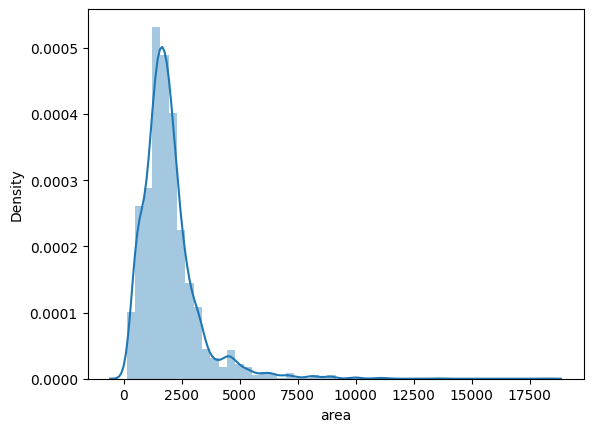

In [104]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

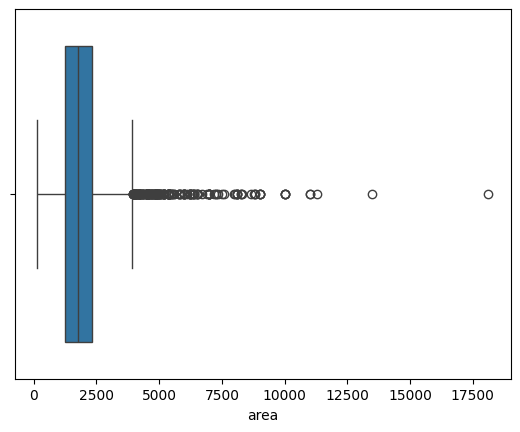

In [105]:
sns.boxplot(x=df['area'])

In [106]:
df['area'].describe()

count     3633.000000
mean      1958.564027
std       1260.114203
min        145.000000
25%       1261.000000
50%       1749.000000
75%       2332.000000
max      18122.000000
Name: area, dtype: float64

In [108]:
df[df['area']>15000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
43,flat,godrej air,sector 85,2.5,1379.0,18122.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,1,1,1,44


In [109]:
df = df[df['area'] <= 15000]

<Axes: xlabel='area', ylabel='Count'>

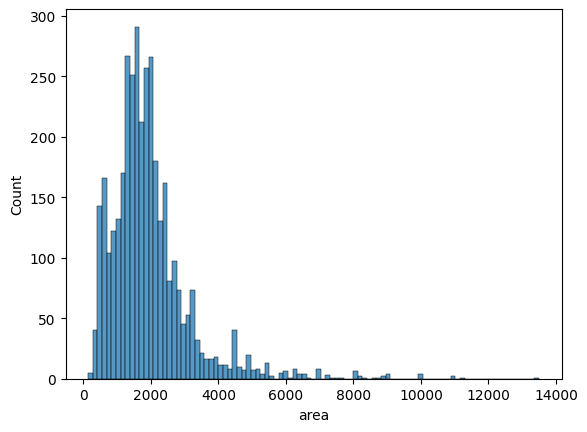

In [110]:
sns.histplot(df['area'])

<Axes: xlabel='area'>

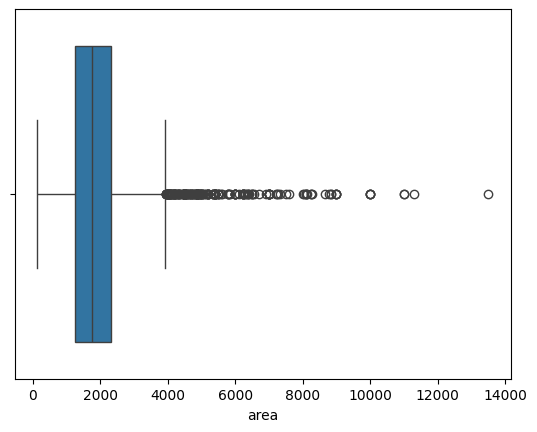

In [111]:
sns.boxplot(x=df['area'])

### Bedroom

C:\Users\user\AppData\Local\Temp\ipykernel_10452\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

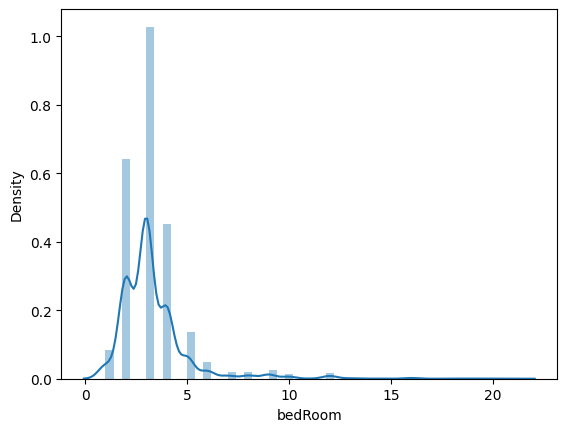

In [112]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

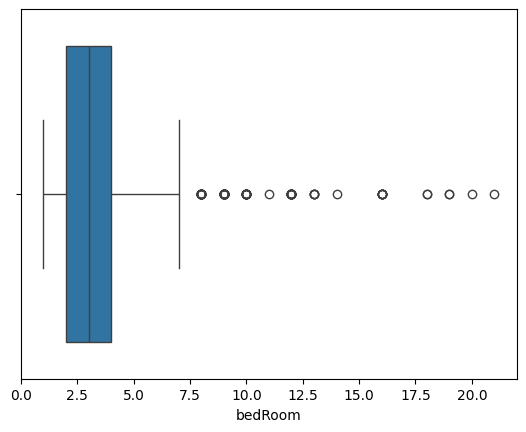

In [113]:
sns.boxplot(x=df['bedRoom'])

In [114]:
df['bedRoom'].describe()

count    3632.000000
mean        3.330672
std         1.825027
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [115]:

df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
354,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,2,49
1619,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,2,22
2779,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
1071,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
2332,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,2,70
2880,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,2,57
1292,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31
1660,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,0,41
3220,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,3078.0,NaN,1,1,1,1,0,1,0
3476,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,1,49


In [116]:
df = df[df['bedRoom'] <= 10]

In [117]:
df.shape

(3587, 23)

C:\Users\user\AppData\Local\Temp\ipykernel_10452\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

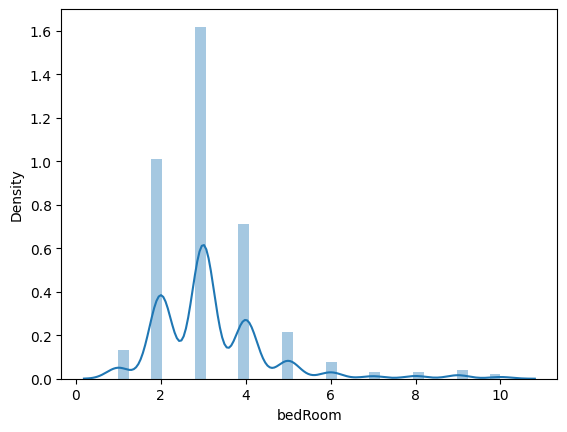

In [118]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

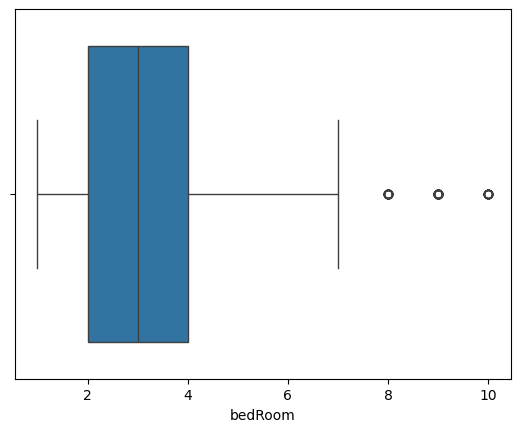

In [119]:
sns.boxplot(x=df['bedRoom'])

In [120]:
df['bedRoom'].describe()

count    3587.000000
mean        3.200725
std         1.386884
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\user\AppData\Local\Temp\ipykernel_10452\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

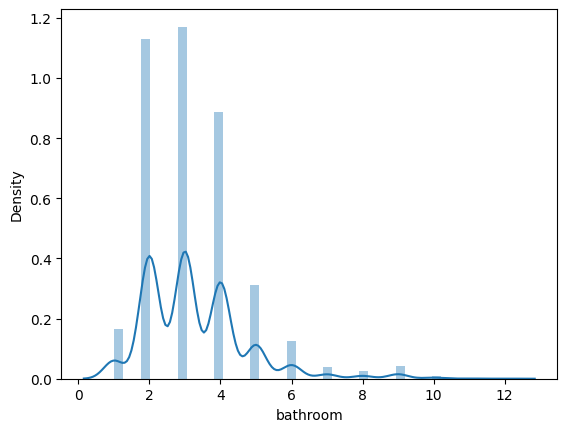

In [121]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

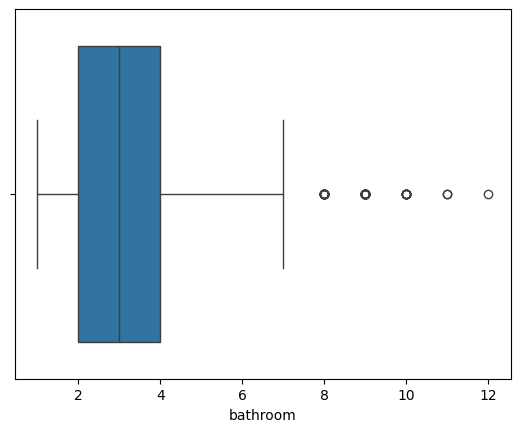

In [122]:
sns.boxplot(x=df['bathroom'])

In [123]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1880,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,1,146
1701,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,1,39
1948,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38


In [124]:

df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80


### super built up area

C:\Users\user\AppData\Local\Temp\ipykernel_10452\939662859.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

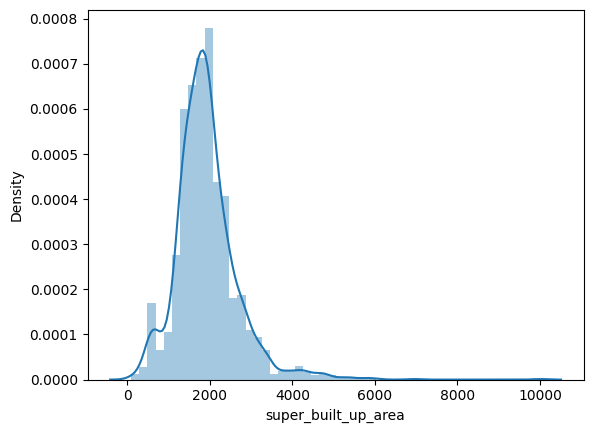

In [125]:

sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

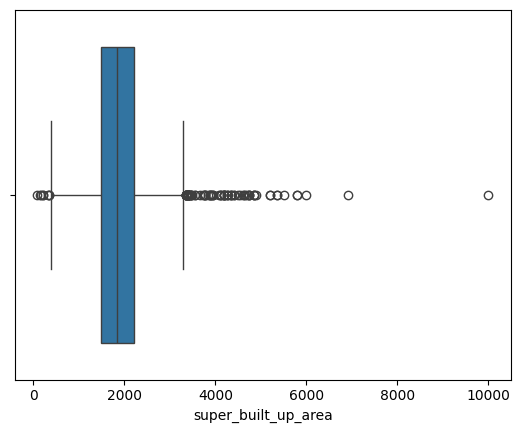

In [126]:
sns.boxplot(x=df['super_built_up_area'])

In [127]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [128]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
23,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140
3789,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49


### built up area

C:\Users\user\AppData\Local\Temp\ipykernel_10452\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

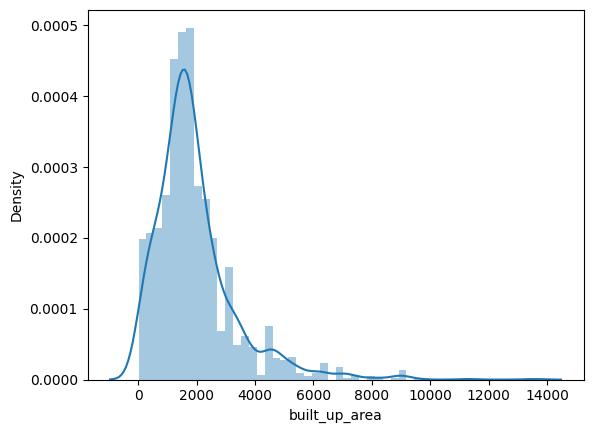

In [129]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

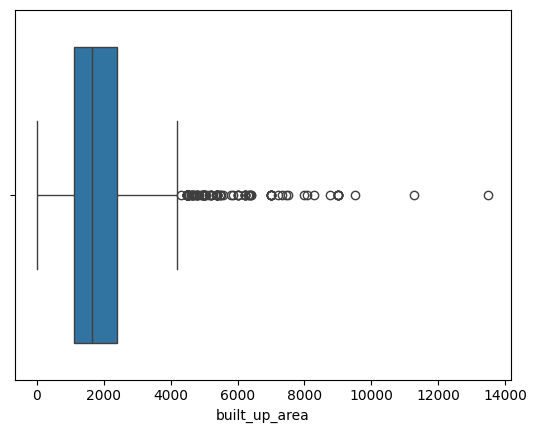

In [130]:
sns.boxplot(x=df['built_up_area'])

In [131]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
676,house,independent,sector 4,0.85,630.0,13500.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0
1164,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42


### carpet area

C:\Users\user\AppData\Local\Temp\ipykernel_10452\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

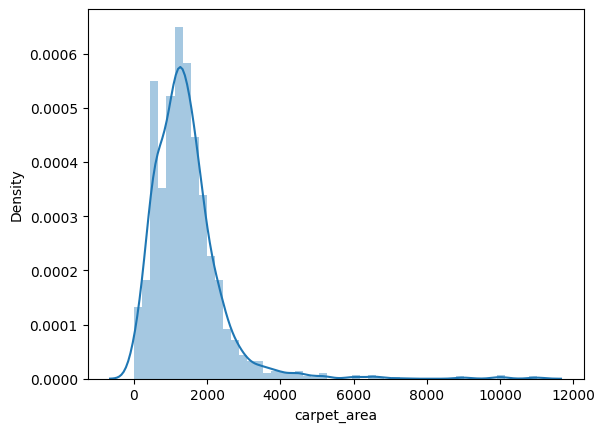

In [132]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

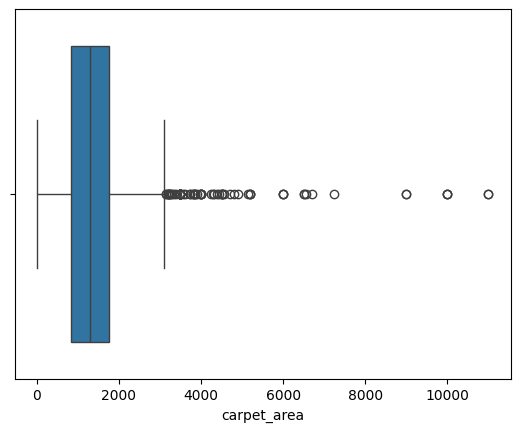

In [133]:
sns.boxplot(x=df['carpet_area'])

In [134]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2775,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
3679,house,independent,sector 26,18.4,1859.0,11000.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,1,60


In [135]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9264.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80


### Luxury Score

C:\Users\user\AppData\Local\Temp\ipykernel_10452\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

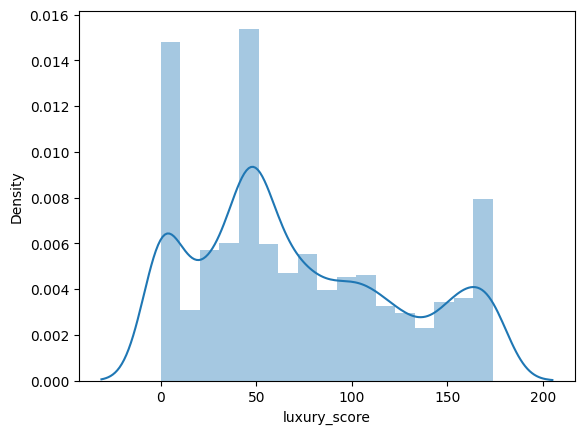

In [136]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

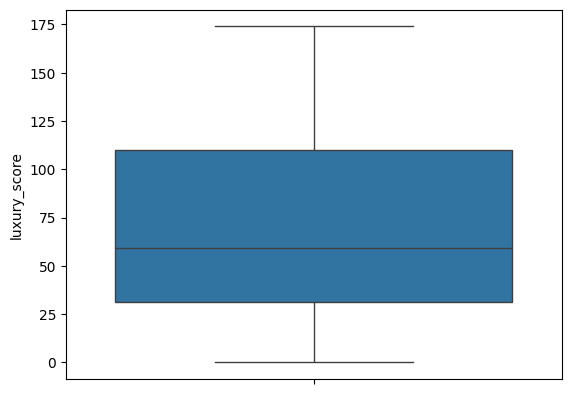

In [137]:
sns.boxplot(df['luxury_score'])

In [138]:
df.shape

(3587, 23)

In [139]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [140]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11429.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9265.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80


C:\Users\user\AppData\Local\Temp\ipykernel_10452\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

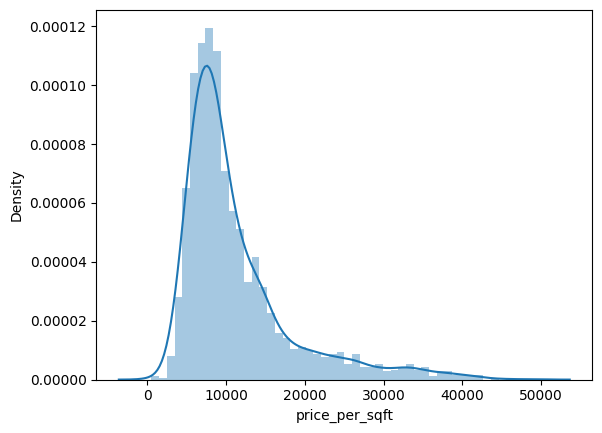

In [141]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

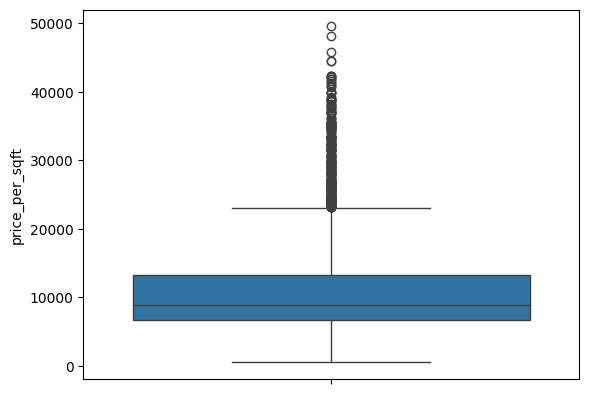

In [142]:
sns.boxplot(df['price_per_sqft'])

In [143]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
45,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,1,44
51,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,1,121
555,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,1,60
666,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
863,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,2,0
1197,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,0,0
1211,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,1,88
1644,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,1,7
3489,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,1,103


In [144]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(252.40000000000003)

In [145]:
df["area_room_ratio"] = df["area"] / df["bedRoom"]

In [146]:
filtered_df = df[(df['area'] / df['bedRoom']) < 250]

filtered_df.to_excel("../reports/outliers/low_area_per_bedroom.xlsx", index=False)

In [147]:
filtered_df['bedRoom'].value_counts()

bedRoom
2     47
3     33
5     28
6     17
4     17
9     15
8     12
7      8
10     7
Name: count, dtype: int64

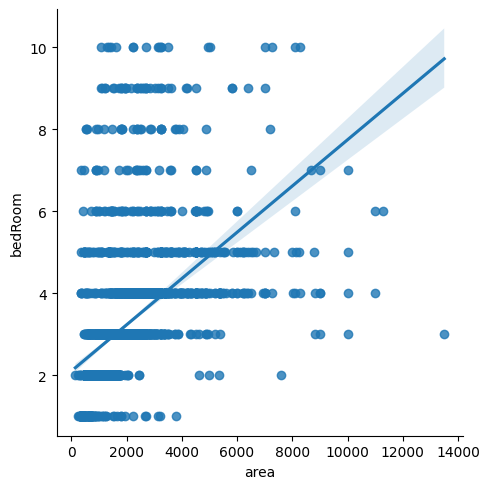

In [148]:
sns.lmplot(x='area', y='bedRoom', data=df)

In [149]:
df[df['area_room_ratio']<100]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
235,house,independent,sector 6,0.50,13889.0,360.0,Plot area 40(33.45 sq.m.),5,3,3,3.0,NaN,Old Property,NaN,360.0,NaN,0,0,0,0,0,0,0,72.000000
345,house,jacobpura,sector 12,0.53,14601.0,363.0,Plot area 360(33.45 sq.m.),4,4,2,3.0,East,Relatively New,NaN,360.0,NaN,0,0,0,0,0,0,0,90.750000
613,house,independent,sector 8,0.49,11239.0,436.0,Plot area 360(33.45 sq.m.),6,3,2,3.0,East,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,0,8,72.666667
937,house,rk excelo,sector 12,0.60,13333.0,450.0,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,5,3,2,3.0,North,Moderately Old,NaN,30.0,15.0,0,0,0,0,1,0,0,90.000000
1011,house,not applicable,sector 4,0.51,14167.0,360.0,Plot area 40(33.45 sq.m.),4,4,3,4.0,NaN,New Property,NaN,360.0,NaN,0,0,0,0,0,0,0,90.000000
1257,house,ss omnia,sector 86,0.42,9333.0,450.0,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,NaN,50.0,NaN,0,0,0,0,0,0,0,90.000000
1390,house,sector 38 rwa,sector 38,1.40,23932.0,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8,8,3,4.0,East,Moderately Old,NaN,62.0,60.0,0,0,0,0,1,1,40,73.125000
1407,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,450.0,NaN,0,0,0,1,0,0,7,64.285714
1641,house,rajendra park gurgaon,sector 105,0.37,10278.0,360.0,Plot area 360(33.45 sq.m.),4,3,2,3.0,East,Relatively New,NaN,360.0,NaN,0,0,0,0,0,0,0,90.000000
2192,house,rattan garden,sector 7,0.83,17585.0,472.0,Carpet area: 472 (43.85 sq.m.),5,3,2,3.0,East,Undefined,NaN,NaN,472.0,0,0,0,0,0,0,0,94.400000


In [150]:
df=df[df['area_room_ratio']>100]

In [151]:
outlier=df[(df['area_room_ratio']<250) & (df['bedRoom']>3)]

In [152]:
outlier

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
31,house,independent,sector 24,4.50,33333.0,1350.0,Plot area 163(136.29 sq.m.)Built Up area: 160 ...,10,8,3+,4.0,East,Relatively New,NaN,160.0,150.0,0,1,1,0,0,1,56,135.00
45,house,independent,sector 55,5.00,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,1,44,125.00
173,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.00
195,house,independent,sector 24,3.50,32407.0,1080.0,Plot area 120(100.34 sq.m.),5,4,3,3.0,North-West,Old Property,NaN,1080.0,NaN,0,0,0,0,0,0,15,216.00
251,house,uppal southend,sector 49,3.75,25562.0,1467.0,Built Up area: 163 (136.29 sq.m.),6,6,3+,3.0,East,Moderately Old,NaN,163.0,NaN,1,0,0,0,0,1,26,244.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,house,independent,sector 47,4.30,29312.0,1467.0,Plot area 163(136.29 sq.m.),6,4,2,2.0,NaN,Moderately Old,NaN,1467.0,NaN,0,0,0,0,1,0,0,244.50
3545,house,independent,sector 12,0.90,13333.0,675.0,Built Up area: 675 (62.71 sq.m.),4,4,0,2.0,NaN,Undefined,NaN,675.0,NaN,0,0,0,0,0,0,0,168.75
3552,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.00
3583,house,independent,sector 13,1.50,11538.0,1300.0,Plot area 1300(120.77 sq.m.),10,7,3,4.0,East,Moderately Old,NaN,1300.0,NaN,0,0,0,0,0,0,0,130.00


In [153]:
outlier['bedRoom']= round(outlier['bedRoom']/outlier['floorNum'])

C:\Users\user\AppData\Local\Temp\ipykernel_10452\994019679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier['bedRoom']= round(outlier['bedRoom']/outlier['floorNum'])


In [154]:
df.update(outlier)

In [155]:
df['area_room_ratio'] = df["area"] / df["bedRoom"]  

In [156]:
df[(df['area_room_ratio']<250) & (df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
173,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.000000
270,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,0,0,166.666667
490,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,Undefined,NaN,NaN,110.0,0,0,0,0,0,0,0,198.000000
692,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,150.000000
1429,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000
1553,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,NaN,67.0,NaN,0,0,0,1,0,0,29,120.600000
1639,house,independent,sector 11,3.50,15556.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10,1,0,1.0,NaN,New Property,NaN,2250.0,NaN,0,0,0,0,0,0,0,225.000000
2197,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,Undefined,NaN,NaN,120.0,0,0,0,0,0,0,0,120.000000
2498,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,1,0,225.000000
2544,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,Undefined,NaN,1100.0,900.0,0,0,0,0,0,0,0,220.000000


In [157]:
df=df[~((df['area_room_ratio']<250) & (df['bedRoom']>4))]

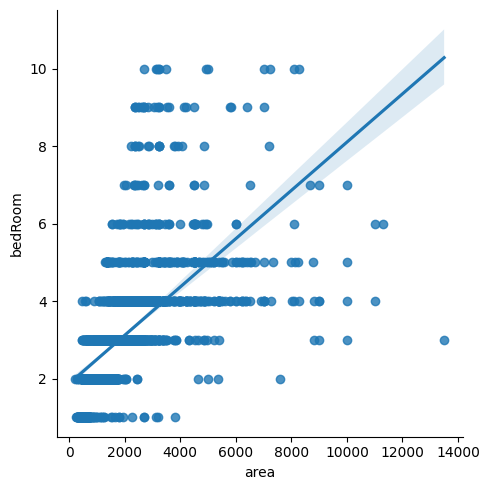

In [158]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [159]:
df.shape

(3554, 24)

In [160]:

# Create the folder if it doesn't exist
os.makedirs("../data/feature_engineered", exist_ok=True)

df.to_csv("../data/feature_engineered/gurgaon_properties_outlier_treated.csv", index=False)

print("Outlier-treated dataset saved successfully!")

Outlier-treated dataset saved successfully!
